In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

np.random.seed(15)

kwh_consume = sorted(np.random.randint(50, 1000, 100), reverse=True)

In [2]:
max_v = max(kwh_consume)
min_v = min(kwh_consume)
amplitude = max_v - min_v

k = 1 + 3.332 * np.log10(len(kwh_consume))
k = round(k)

h = amplitude / k
h = round(h)


print(f'max, min:  {max_v.item()}, {min_v.item()}')
print(f'amplitude: {amplitude}')
print(f'k:         {k}')
print(f'h:         {h}')

max, min:  993, 51
amplitude: 942
k:         8
h:         118


In [3]:
intervals = []
start = min_v

for i in range(k):
    end = start + h
    intervals.append((start, end))
    start = end

In [4]:
interval_bastions = []
for i in intervals:
    interval_bastions.append(i[0])
interval_bastions.append(intervals[-1][1])

In [5]:
data = pd.Series(kwh_consume)

idx = pd.interval_range(start=min_v, end=interval_bastions[-1], periods=k, closed='left')
df = pd.DataFrame(index=idx)
df.index

IntervalIndex([ [51, 169), [169, 287), [287, 405), [405, 523), [523, 641),
               [641, 759), [759, 877), [877, 995)],
              dtype='interval[int64, left]')

In [6]:
counts = pd.cut(data, bins=interval_bastions, right=False).value_counts().sort_index()
df['fi'] = counts.values
df['fr'] = df['fi'] / len(kwh_consume)
df['fraci'] = df['fr'].cumsum()
df['pmi'] = [interval.mid for interval in df.index]

In [7]:
df

,fi,fr,fraci,pmi
"[51, 169)",16,0.16,0.16,110.0
"[169, 287)",11,0.11,0.27,228.0
"[287, 405)",14,0.14,0.41,346.0
"[405, 523)",13,0.13,0.54,464.0
"[523, 641)",8,0.08,0.62,582.0
"[641, 759)",7,0.07,0.69,700.0
"[759, 877)",15,0.15,0.84,818.0
"[877, 995)",16,0.16,1.00,936.0


In [8]:
mean = data.mean()
median = data.median()
mode = data.mode().iloc[0]

std = data.std()
cv = (std / mean) * 100

print(f"mean:    {mean}")
print(f"median:  {median}")
print(f"mode:    {mode}")
print(f"cv:      {cv:.3f}%")

mean:    521.91
median:  491.0
mode:    368
cv:      57.031%


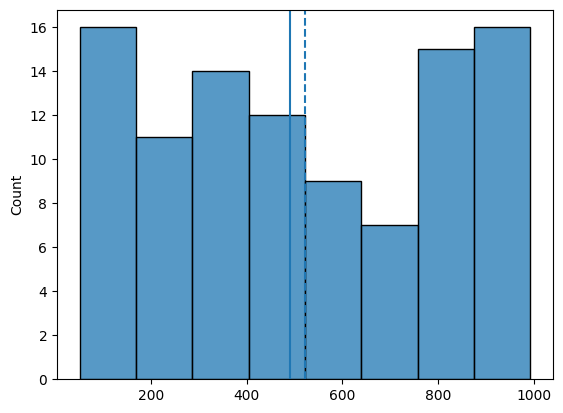

In [9]:
sns.histplot(kwh_consume) # o sns já automatiza tudo (k,h), dessa eu não sabia
plt.axvline(mean, linestyle='--')
plt.axvline(median, linestyle='-')


A média não é tão representativa pois não está em um centro de massa na distribuição, o cv > 30% também indica isso. A distribuição é assimétrica bimodal, tendo dois picos, um a esquerda e outro a direita. As faixas mais comuns, com 16 elementos cada são [51, 169) e [877, 995)
